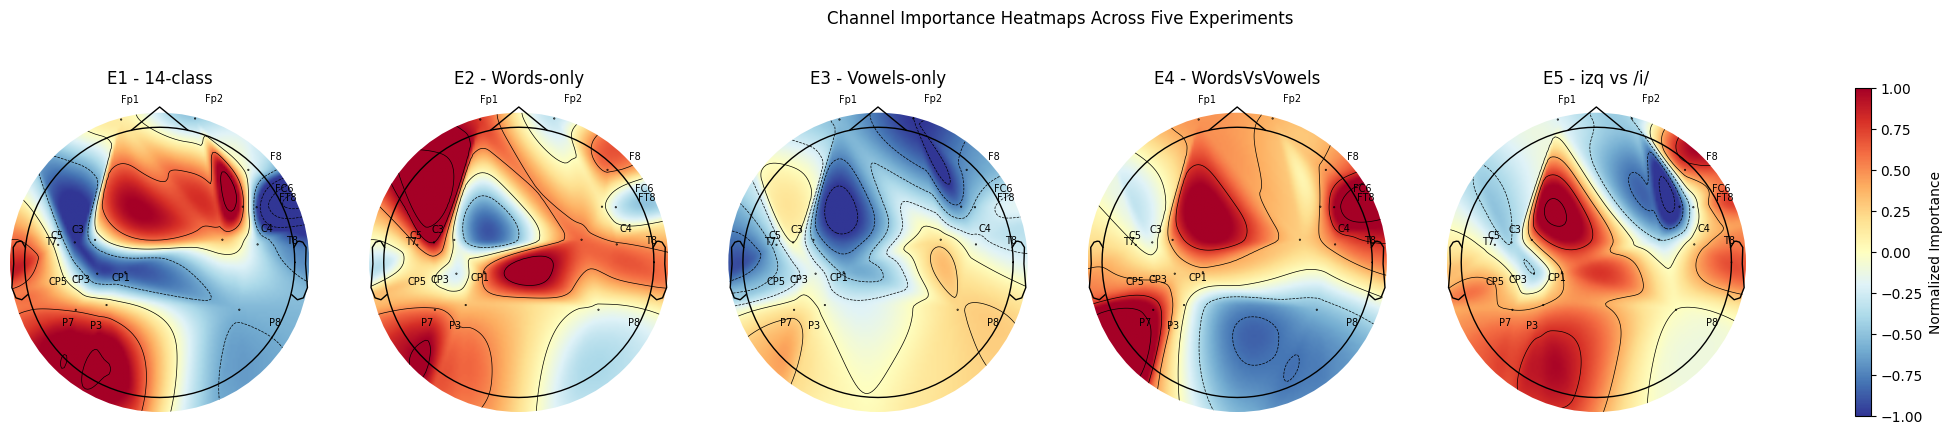


Ranking por experimento
importance = baseline_mean - ablation_mean


E1 - 14-class
--------------------------------------------------
Más importantes:
Canal_9 | FC6 | importance=0.7143
Canal_14 | P7 | importance=0.5952
Canal_11 | C4 | importance=0.3571
Canal_7 | P3 | importance=0.2381
Canal_0 | Fp1 | importance=0.1190

Menos importantes o redundantes:
Canal_15 | P8 | importance=-0.5952
Canal_10 | FT8 | importance=-0.9524
Canal_5 | CP3 | importance=-0.9524
Canal_4 | CP1 | importance=-0.9524
Canal_2 | C5 | importance=-1.0714

E2 - Words-only
--------------------------------------------------
Más importantes:
Canal_2 | C5 | importance=2.4074
Canal_0 | Fp1 | importance=1.8519
Canal_11 | C4 | importance=1.4815
Canal_3 | T7 | importance=1.2963
Canal_4 | CP1 | importance=1.2963

Menos importantes o redundantes:
Canal_15 | P8 | importance=-0.1852
Canal_1 | C3 | importance=-0.1852
Canal_10 | FT8 | importance=-0.5556
Canal_5 | CP3 | importance=-0.5556
Canal_8 | Fp2 | importance=-0.7407

E3 - Vo

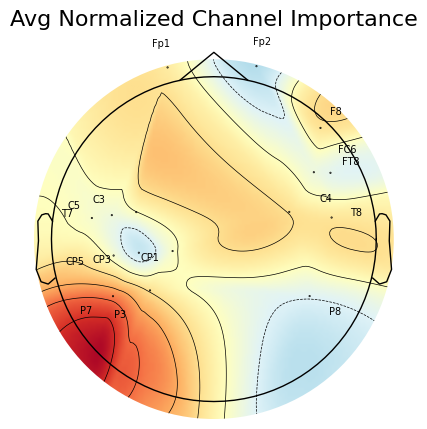


Ranking global promedio
Promedio de importancias normalizadas por experimento

Más importantes globalmente:
Canal_14 | P7 | global_importance=0.5296
Canal_11 | C4 | global_importance=0.1931
Canal_7 | P3 | global_importance=0.1811
Canal_12 | F8 | global_importance=0.1617
Canal_13 | T8 | global_importance=0.1555

Menos importantes o redundantes globalmente:
Canal_9 | FC6 | global_importance=-0.1055
Canal_10 | FT8 | global_importance=-0.1562
Canal_15 | P8 | global_importance=-0.1856
Canal_5 | CP3 | global_importance=-0.2821
Canal_8 | Fp2 | global_importance=-0.3567


In [ ]:
# =========================================================
# Instalar MNE
# =========================================================
!pip install mne -q

# =========================================================
# Librerías
# =========================================================
import mne
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# Canales EEG
# =========================================================
channels = [
    'Fp1','C3','C5','T7',
    'CP1','CP3','CP5','P3',
    'Fp2','FC6','FT8','C4',
    'F8','T8','P7','P8'
]

# =========================================================
# Importancia por experimento
# importance = baseline_mean - ablation_mean
# =========================================================
experiments = {
    "E1 - 14-class": np.array([
         0.119047546,
        -0.357143402,
        -1.071429062,
        -0.238095474,
        -0.952382278,
        -0.952382278,
        -0.357143402,
         0.238095474,
        -0.476191330,
         0.714285660,
        -0.952382278,
         0.357143021,
        -0.119047928,
        -0.357143784,
         0.595237732,
        -0.595238876
    ]),

    "E2 - Words-only": np.array([
         1.851851845,
        -0.185185814,
         2.407407379,
         1.296296692,
         1.296296501,
        -0.555555725,
        -0.000000191,
         0.740740967,
        -0.740740967,
         0.185184860,
        -0.555555725,
         1.481481361,
         1.296296120,
         1.296295929,
         1.296296501,
        -0.18518
    ]),

    "E3 - Vowels-only": np.array([
        -2.333333397,
        -2.333333778,
        -0.000000191,
        -1.666667366,
        -2.333334160,
        -0.666666794,
        -1.333333969,
        -0.333333588,
        -4.333333397,
        -3.000000572,
        -2.000000381,
         0.666666031,
        -3.000000954,
        -0.666666603,
         0.666666031,
         0.9999998
    ]),

    "E4 - WordsVsVowels": np.array([
         1.500000763,
         1.666667175,
        -0.333332062,
         0.000000000,
         1.000001526,
         0.833332825,
         1.000001526,
         0.166666412,
         1.166667175,
         1.333334351,
         3.166666412,
         0.833332825,
         1.500000000,
         1.666667175,
         3.166666794,
        -1.666664886
    ]),
        "E5 - izq vs /i/": np.array([
        -0.833333588,
         1.666667175,
        -1.666665649,
        -0.833331299,
         1.666667175,
        -1.666665649,
         0.000001526,
         1.666667938,
        -1.666666412,
        -4.166665649,
        -0.833332825,
        -1.666666412,
         2.500001526,
         0.833333588,
         1.666667938,
         0.000000763
    ])

}

# =========================================================
# Crear info EEG y montaje 10-20
# =========================================================
info = mne.create_info(
    ch_names=channels,
    sfreq=125,
    ch_types='eeg'
)

montage = mne.channels.make_standard_montage('standard_1020')
info.set_montage(montage)

# =========================================================
# Figura con los cinco mapas
# =========================================================
fig, axes = plt.subplots(1, 5, figsize=(28, 5))

for ax, (exp_name, importance) in zip(axes, experiments.items()):

    importance_norm = importance / np.max(np.abs(importance))

    im, cn = mne.viz.plot_topomap(
        importance_norm,
        info,
        axes=ax,
        show=False,
        cmap='RdYlBu_r',
        contours=6,
        sensors=True,
        res=128,
        vlim=(-1, 1)
    )

    for idx, ch in enumerate(channels):
        pos = info['chs'][idx]['loc'][:2]

        ax.text(
            pos[0] + .01,
            pos[1],
            ch,
            fontsize=7,
            ha='center',
            va='center',
            color='black'
        )

    ax.set_title(exp_name, fontsize=12)

cbar = fig.colorbar(
    im,
    ax=axes,
    shrink=0.85,
    location='right'
)

cbar.set_label('Normalized Importance')

fig.suptitle(
    'Channel Importance Heatmaps Across Five Experiments',
    fontsize=12
)

plt.show()

# =========================================================
# Ranking por experimento
# =========================================================
print("\nRanking por experimento")
print("importance = baseline_mean - ablation_mean\n")

for exp_name, importance in experiments.items():

    print(f"\n{exp_name}")
    print("-" * 50)

    idx_sorted = np.argsort(importance)[::-1]

    print("Más importantes:")
    for idx in idx_sorted[:5]:
        print(
            f"Canal_{idx} | {channels[idx]} | "
            f"importance={importance[idx]:.4f}"
        )

    print("\nMenos importantes o redundantes:")
    for idx in idx_sorted[-5:]:
        print(
            f"Canal_{idx} | {channels[idx]} | "
            f"importance={importance[idx]:.4f}"
        )

# =========================================================
# Importancia global promedio
# =========================================================
all_importances = np.array(list(experiments.values()))

# Normalización por experimento antes de promediar
all_importances_norm = np.array([
    imp / np.max(np.abs(imp))
    for imp in all_importances
])

global_importance = np.mean(all_importances_norm, axis=0)

# =========================================================
# Mapa global
# =========================================================
fig, ax = plt.subplots(figsize=(5, 5))

im, cn = mne.viz.plot_topomap(
    global_importance,
    info,
    axes=ax,
    show=False,
    cmap='RdYlBu_r',
    contours=6,
    sensors=True,
    res=128,
    vlim=(-1, 1)
)

for idx, ch in enumerate(channels):
    pos = info['chs'][idx]['loc'][:2]

    ax.text(
        pos[0],
        pos[1],
        ch,
        fontsize=7,
        ha='center',
        va='center',
        color='black'
    )

ax.set_title(
    'Avg Normalized Channel Importance',
    fontsize=16
)

#cbar = plt.colorbar(im, ax=ax)
#cbar.set_label('Average Normalized Importance')

plt.show()

# =========================================================
# Ranking global
# =========================================================
print("\nRanking global promedio")
print("Promedio de importancias normalizadas por experimento\n")

idx_sorted_global = np.argsort(global_importance)[::-1]

print("Más importantes globalmente:")
for idx in idx_sorted_global[:5]:
    print(
        f"Canal_{idx} | {channels[idx]} | "
        f"global_importance={global_importance[idx]:.4f}"
    )

print("\nMenos importantes o redundantes globalmente:")
for idx in idx_sorted_global[-5:]:
    print(
        f"Canal_{idx} | {channels[idx]} | "
        f"global_importance={global_importance[idx]:.4f}"
    )